In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import os
import itertools
import seaborn as sns
import matplotlib.cm as cm
import matplotlib.colors as mcolors

---

---

# LOSSES COMPARISON

In [15]:
# def plot_losses(loss_data):
#     # Unwrap the dictionary if it's stored inside a NumPy 0D array
#     if isinstance(loss_data, np.ndarray):
#         loss_data = loss_data.item()

#     # Determine epochs starting from 1 up to N
#     num_epochs = len(loss_data['train_loss'])
#     epochs = range(1, num_epochs + 1)

#     # Setup figure
#     plt.figure(figsize=(8, 5))

#     # Plot each loss metric
#     plt.plot(epochs, loss_data['train_loss'], label='Train Loss', marker='o')
#     plt.plot(epochs, loss_data['val_loss'], label='Validation Loss', marker='s')
#     plt.plot(epochs, loss_data['test_loss'], label='Test Loss', marker='^')

#     # Formatting
#     plt.title('Training, Validation, and Test Loss over Epochs', fontsize=12, fontweight='bold')
#     plt.xlabel('Epoch', fontsize=11)
#     plt.ylabel('Loss', fontsize=11)
#     plt.xticks(epochs)  # Show integer ticks for all epochs
#     plt.grid(True, linestyle='--', alpha=0.6)
#     plt.legend(frameon=True)
#     plt.tight_layout()

#     plt.show()

In [3]:
# losses = np.load("./checkpoints/sl96_pl96_dm64_el2_tk5/loss_history.npy", allow_pickle=True)

# plot_losses(losses)

In [4]:
# losses = np.load("./checkpoints/TCN_sl96_pl96_dm64_el2_tk5/loss_history.npy", allow_pickle=True)

# plot_losses(losses)

In [28]:
def plot_losses_all(
    ax,
    loss_data,
    title="",
    show_legend=False,
    show_ylabel=False,
    show_xlabel=False,
):
    if isinstance(loss_data, np.ndarray):
        loss_data = loss_data.item()

    num_epochs = len(loss_data["train_loss"])
    epochs = np.arange(1, num_epochs + 1)

    ax.plot(epochs, loss_data["train_loss"], label="Train Loss", marker="o")
    ax.plot(epochs, loss_data["val_loss"], label="Validation Loss", marker="s")
    ax.plot(epochs, loss_data["test_loss"], label="Test Loss", marker="^")

    ax.set_title(title, fontsize=12, fontweight="bold")

    if show_xlabel:
        ax.set_xlabel("Epoch", fontsize=12)
    if show_ylabel:
        ax.set_ylabel("Loss", fontsize=12)

    # Vector 1-10 on x-axis across all plots
    ax.set_xticks(np.arange(1, 11))
    ax.set_xlim(0.5, 10.5)

    ax.grid(True, linestyle="--", alpha=0.6)

    if show_legend:
        ax.legend(frameon=True, fontsize=12)

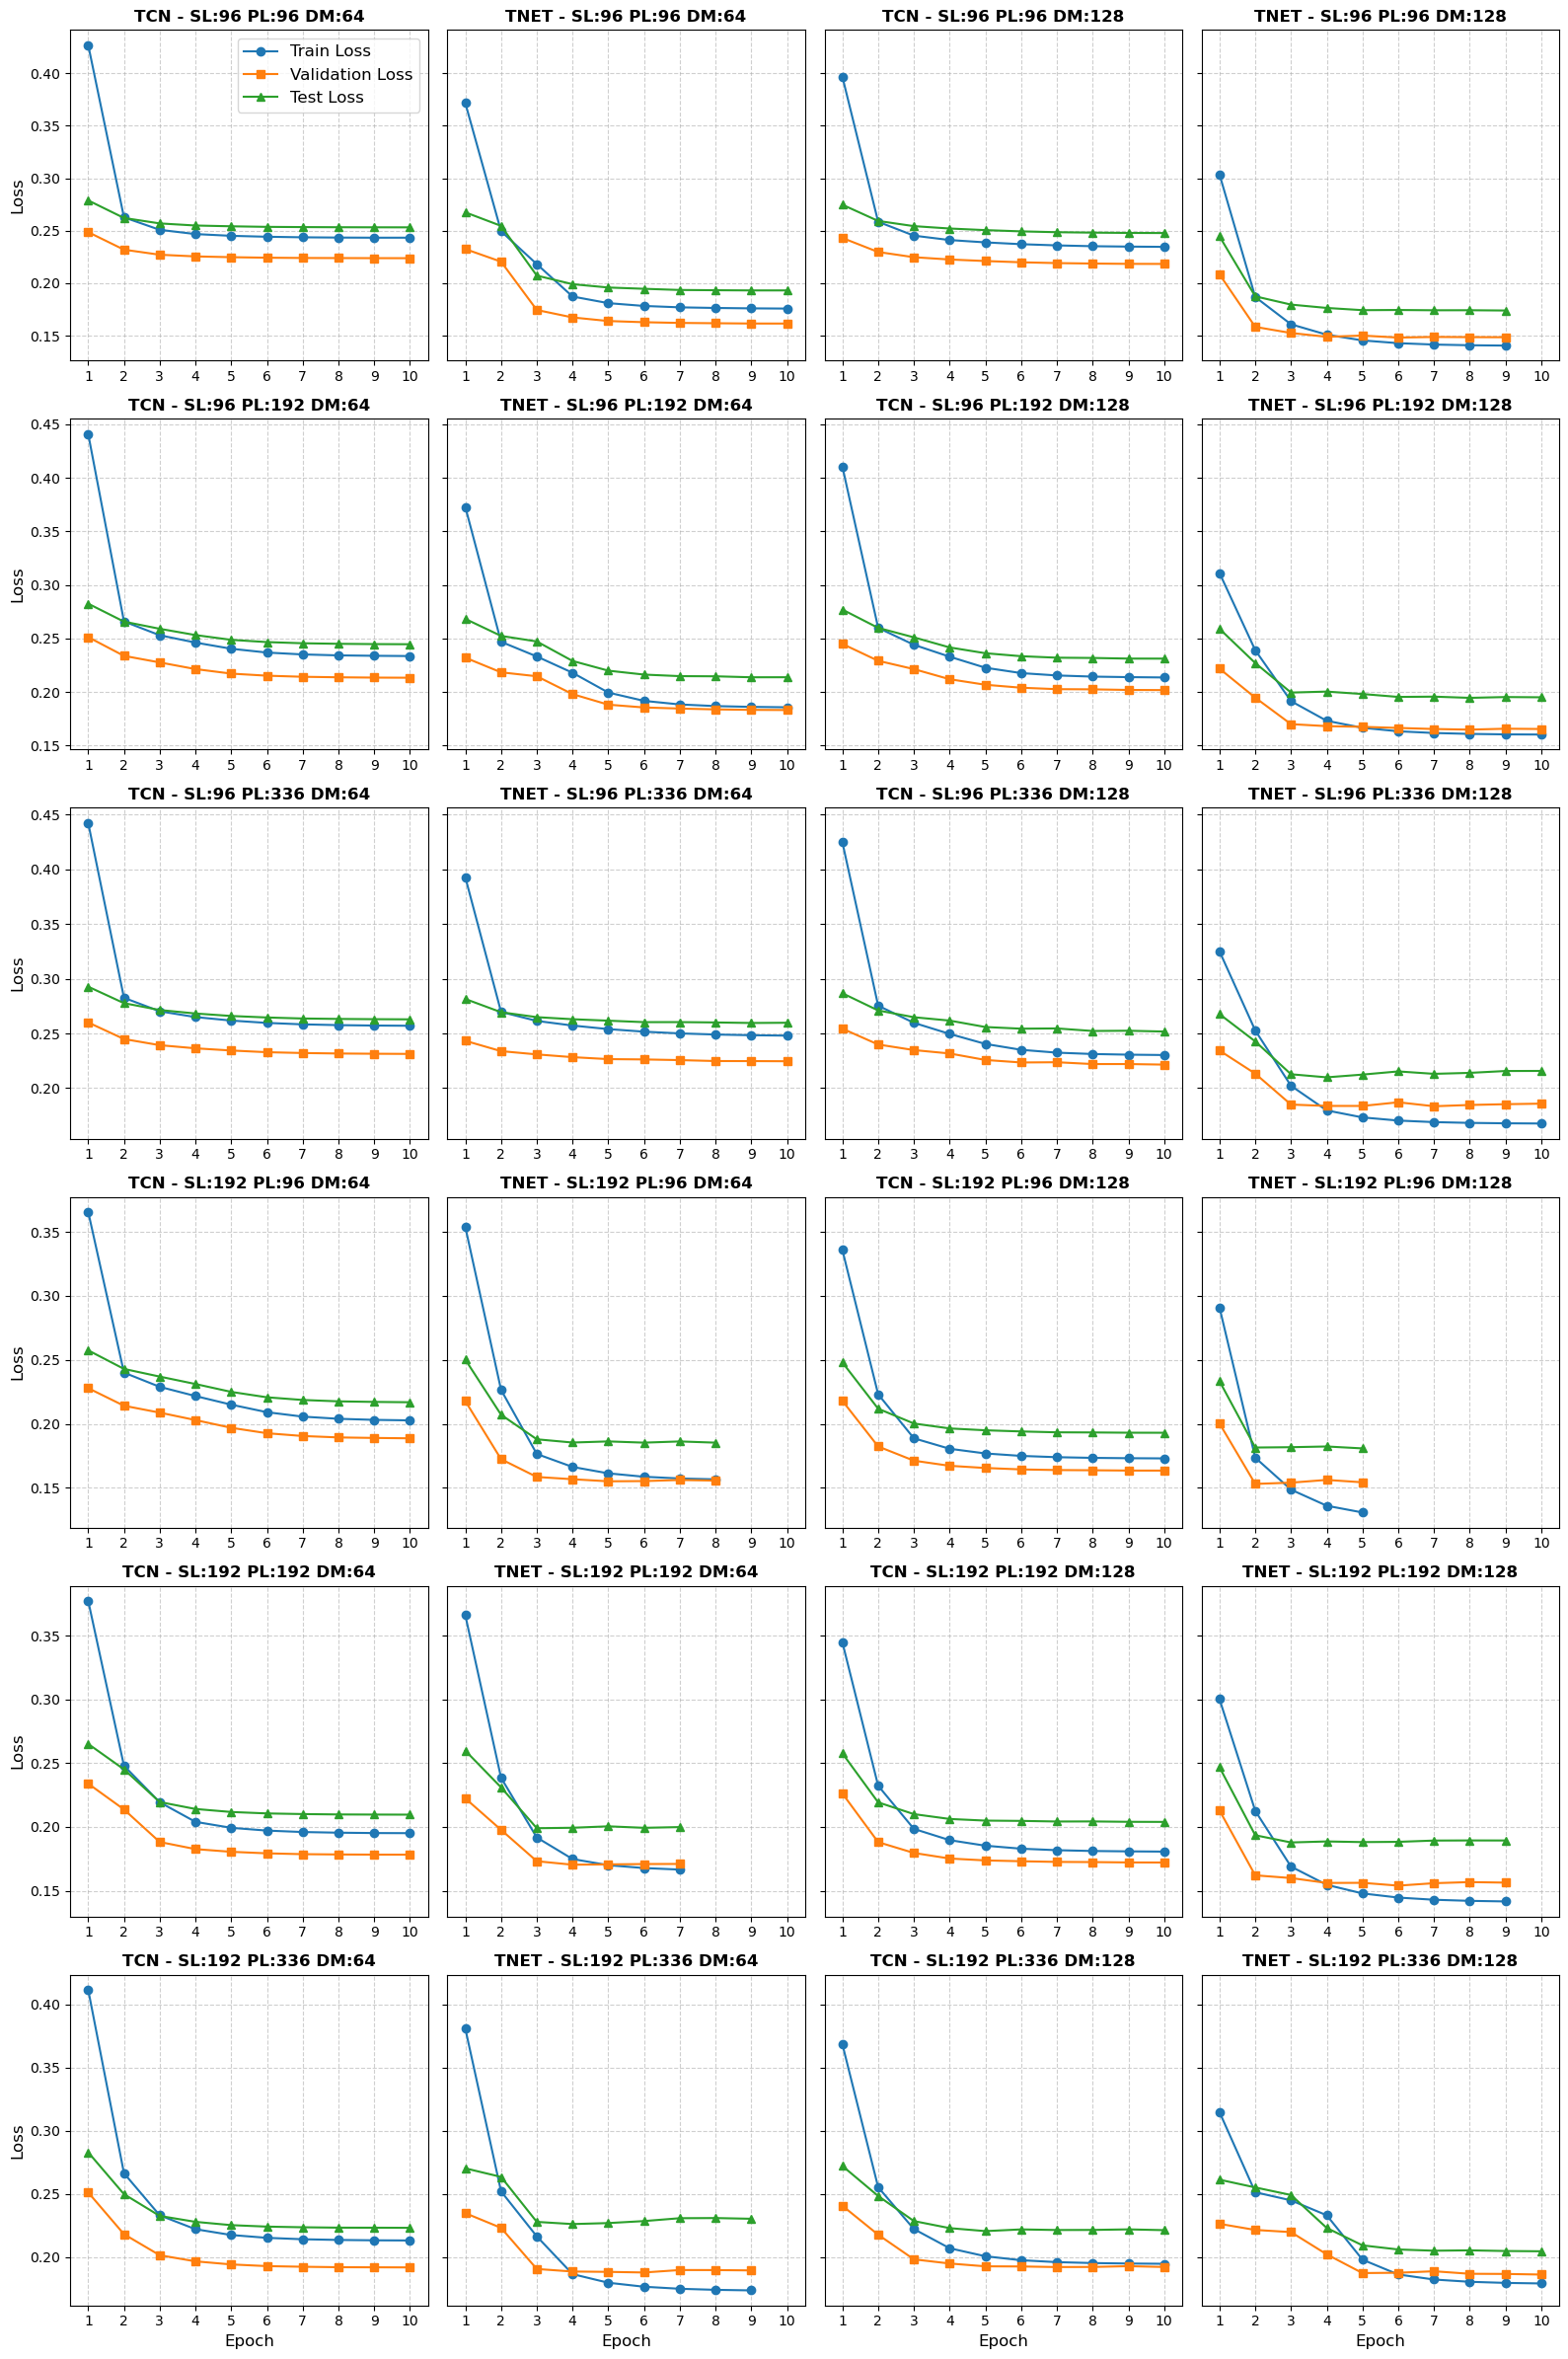

In [29]:
seq_lengths = [96, 192]
pred_lengths = [96, 192, 336]
d_models = [64, 128]

# Create all pairs of hyperparams sl-pl (rows)
param_pairs = list(itertools.product(seq_lengths, pred_lengths))
num_rows = len(param_pairs)

# Models and d_models configuration for the 4 columns
# Col 0: TCN (dm=64), Col 1: TNET (dm=64), Col 2: TCN (dm=128), Col 3: TNET (dm=128)
models = [("TCN", "TCN"), ("TimesNet", "TNET")]
col_configs = []
for dm in d_models:
    for model_folder, label in models:
        col_configs.append((model_folder, label, dm))

num_cols = len(col_configs)  # 4 columns

# Create subplots sharing y-axis across each row
fig, axs = plt.subplots(
    num_rows, num_cols, figsize=(16, 4 * num_rows), sharey="row"
)

# Ensure axs is a 2D array even if num_rows == 1
if num_rows == 1:
    axs = np.expand_dims(axs, axis=0)

for r, (sl, pl) in enumerate(param_pairs):
    is_bottom_row = r == num_rows - 1

    for c, (model_folder, label, dm) in enumerate(col_configs):
        ax = axs[r, c]
        is_leftmost_col = c == 0
        is_first_plot = r == 0 and c == 0

        path = f"./checkpoints/{model_folder}_sl{sl}_pl{pl}_dm{dm}_el2_tk5/loss_history.npy"

        try:
            losses = np.load(path, allow_pickle=True)
            plot_losses_all(
                ax,
                losses,
                title=f"{label} - SL:{sl} PL:{pl} DM:{dm}",
                show_legend=is_first_plot,
                show_ylabel=is_leftmost_col,
                show_xlabel=is_bottom_row,
            )
        except FileNotFoundError:
            ax.set_title(
                f"Missing {label} (SL:{sl}, PL:{pl}, DM:{dm})",
                fontsize=8,
                color="red",
            )
            ax.set_xticks(np.arange(1, 11))
            ax.set_xlim(0.5, 10.5)

            if is_leftmost_col:
                ax.set_ylabel("Loss", fontsize=12)
            if is_bottom_row:
                ax.set_xlabel("Epoch", fontsize=12)

plt.tight_layout()
plt.show()

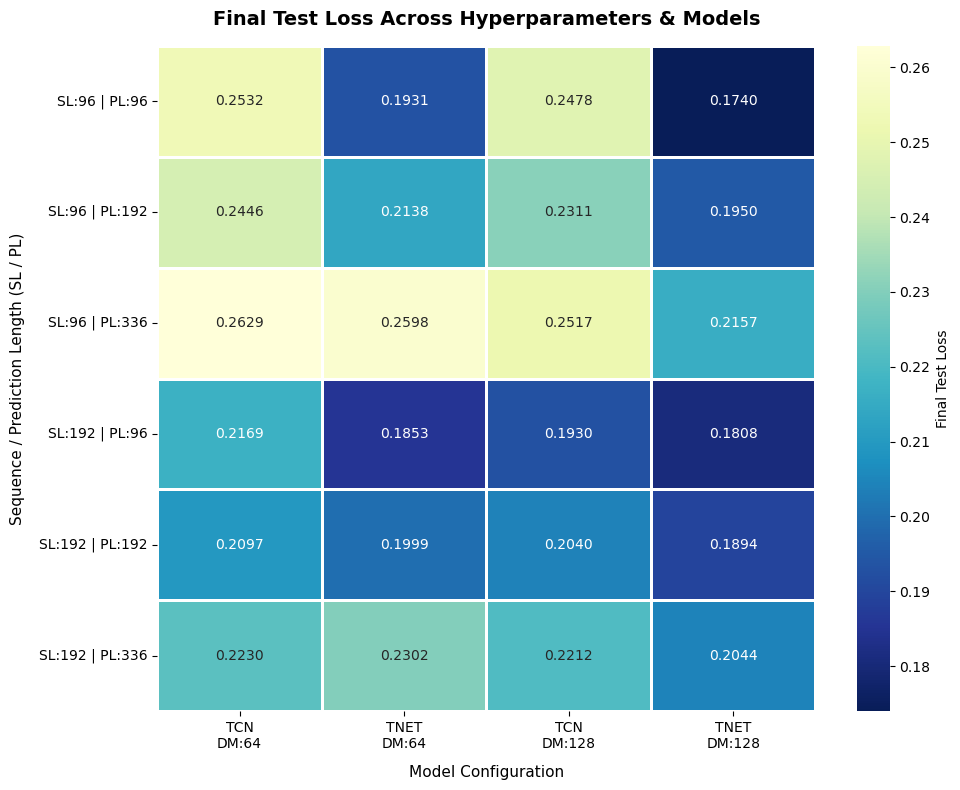

In [32]:
# --- Parameters ---
seq_lengths = [96, 192]
pred_lengths = [96, 192, 336]
d_models = [64, 128]

models = [("TCN", "TCN"), ("TimesNet", "TNET")]

# 1. Generate Row and Column structure
param_pairs = list(itertools.product(seq_lengths, pred_lengths))  # 6 rows
col_configs = []  # 4 columns: TCN-64, TNET-64, TCN-128, TNET-128
for dm in d_models:
    for model_folder, label in models:
        col_configs.append((model_folder, label, dm))

num_rows = len(param_pairs)
num_cols = len(col_configs)

# 2. Extract final test loss values into a 2D matrix
loss_matrix = np.full((num_rows, num_cols), np.nan)

for r, (sl, pl) in enumerate(param_pairs):
    for c, (model_folder, label, dm) in enumerate(col_configs):
        path = f"./checkpoints/{model_folder}_sl{sl}_pl{pl}_dm{dm}_el2_tk5/loss_history.npy"
        try:
            losses = np.load(path, allow_pickle=True)
            if isinstance(losses, np.ndarray):
                losses = losses.item()

            # Take the LAST value of the test loss
            final_test_loss = losses["test_loss"][-1]
            loss_matrix[r, c] = final_test_loss
        except (FileNotFoundError, KeyError, IndexError):
            loss_matrix[r, c] = np.nan  # Leave NaN if file or key is missing

# 3. Build Axis Labels
row_labels = [f"SL:{sl} | PL:{pl}" for sl, pl in param_pairs]
col_labels = [f"{label}\nDM:{dm}" for _, label, dm in col_configs]

# 4. Plot the 2D Heatmap
plt.figure(figsize=(10, 8))

# Use seaborn heatmap for automatic annotations and colorbar formatting
ax = sns.heatmap(
    loss_matrix,
    annot=True,  # Write the numerical loss inside each cell
    fmt=".4f",  # Format as floating point with 4 decimal places
    cmap="YlGnBu_r",  # Reversed color map: darker/greener = lower (better) loss
    xticklabels=col_labels,
    yticklabels=row_labels,
    cbar_kws={"label": "Final Test Loss"},
    linewidths=1,
    linecolor="white",
    mask=np.isnan(
        loss_matrix
    ),  # Mask NaN cells (missing checkpoints will show grey/blank)
)

plt.title(
    "Final Test Loss Across Hyperparameters & Models",
    fontsize=14,
    fontweight="bold",
    pad=15,
)
plt.xlabel("Model Configuration", fontsize=11, labelpad=10)
plt.ylabel("Sequence / Prediction Length (SL / PL)", fontsize=11, labelpad=10)
plt.xticks(rotation=0)
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

/tmp/ipykernel_10550/1769557245.py:59: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap("YlGnBu_r")  # Cooler/darker green-blue for low loss
/tmp/ipykernel_10550/1769557245.py:103: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


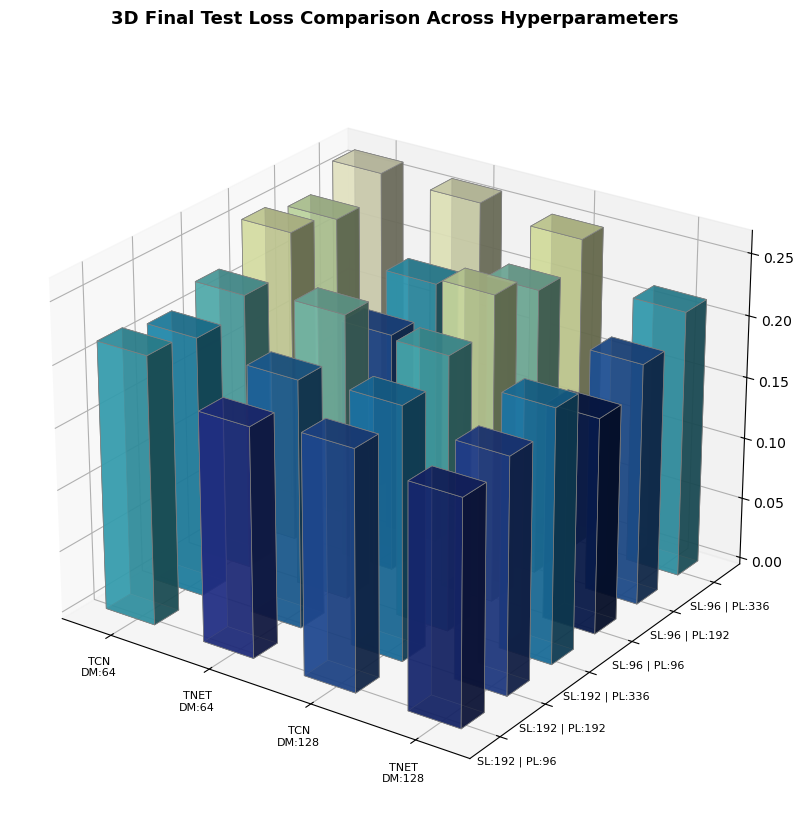

In [39]:
# --- Parameters (Reversed order for SL and PL to keep lowest values in front) ---
seq_lengths = [192, 96]
pred_lengths = [96, 192, 336]
d_models = [64, 128]

models = [("TCN", "TCN"), ("TimesNet", "TNET")]

# 1. Generate Row and Column structure
param_pairs = list(itertools.product(seq_lengths, pred_lengths))  # 6 rows
col_configs = []  # 4 columns: TCN-64, TNET-64, TCN-128, TNET-128
for dm in d_models:
    for model_folder, label in models:
        col_configs.append((model_folder, label, dm))

num_rows = len(param_pairs)
num_cols = len(col_configs)

# 2. Extract final test loss values into a 2D matrix
loss_matrix = np.full((num_rows, num_cols), np.nan)

for r, (sl, pl) in enumerate(param_pairs):
    for c, (model_folder, label, dm) in enumerate(col_configs):
        path = f"./checkpoints/{model_folder}_sl{sl}_pl{pl}_dm{dm}_el2_tk5/loss_history.npy"
        try:
            losses = np.load(path, allow_pickle=True)
            if isinstance(losses, np.ndarray):
                losses = losses.item()

            # Extract last test loss
            final_test_loss = losses["test_loss"][-1]
            loss_matrix[r, c] = final_test_loss
        except (FileNotFoundError, KeyError, IndexError):
            loss_matrix[r, c] = np.nan

# 3. Setup 3D Plot Data
fig = plt.figure(figsize=(14, 10))
ax = fig.add_subplot(111, projection="3d")

# Meshgrid for base positions (X = Columns/Models, Y = Rows/Hyperparams)
_x = np.arange(num_cols)
_y = np.arange(num_rows)
_xx, _yy = np.meshgrid(_x, _y)

xpos = _xx.ravel()
ypos = _yy.ravel()
zpos = np.zeros_like(xpos)

# Bar dimensions
dx = 0.5 * np.ones_like(zpos)
dy = 0.5 * np.ones_like(zpos)
dz = np.nan_to_num(
    loss_matrix.ravel(), nan=0.0
)  # Convert NaNs to 0 height for missing data

# Color map mapping based on height (loss magnitude)
norm = mcolors.Normalize(
    vmin=np.nanmin(loss_matrix), vmax=np.nanmax(loss_matrix)
)
cmap = cm.get_cmap("YlGnBu_r")  # Cooler/darker green-blue for low loss
colors = cmap(norm(dz))

# Apply transparency (alpha = 0.75) to prevent complete occlusion
for i in range(len(colors)):
    if np.isnan(loss_matrix.ravel()[i]):
        colors[i] = [0, 0, 0, 0]  # Fully transparent for missing data
    else:
        colors[i][3] = 0.75  # Set alpha channel

# 4. Draw 3D Bars
ax.bar3d(
    xpos - 0.25,
    ypos - 0.25,
    zpos,
    dx,
    dy,
    dz,
    color=colors,
    edgecolor="gray",
    linewidth=0.5,
)

# 5. Axis Formatting & Labels
col_labels = [f"{label}\nDM:{dm}" for _, label, dm in col_configs]
row_labels = [f"SL:{sl} | PL:{pl}" for sl, pl in param_pairs]

ax.set_xticks(_x)
ax.set_xticklabels(col_labels, fontsize=8)

ax.set_yticks(_y)
ax.set_yticklabels(row_labels, fontsize=8)

ax.set_zlabel("Final Test Loss", fontsize=10, labelpad=10)
ax.set_title(
    "3D Final Test Loss Comparison Across Hyperparameters",
    fontsize=13,
    fontweight="bold",
    pad=20,
)

# Adjust initial viewing angle (elevation, azimuth) for best depth perspective
ax.view_init(elev=25, azim=-55)

plt.tight_layout()
plt.show()

---

# LOSSES OVER K VALUES

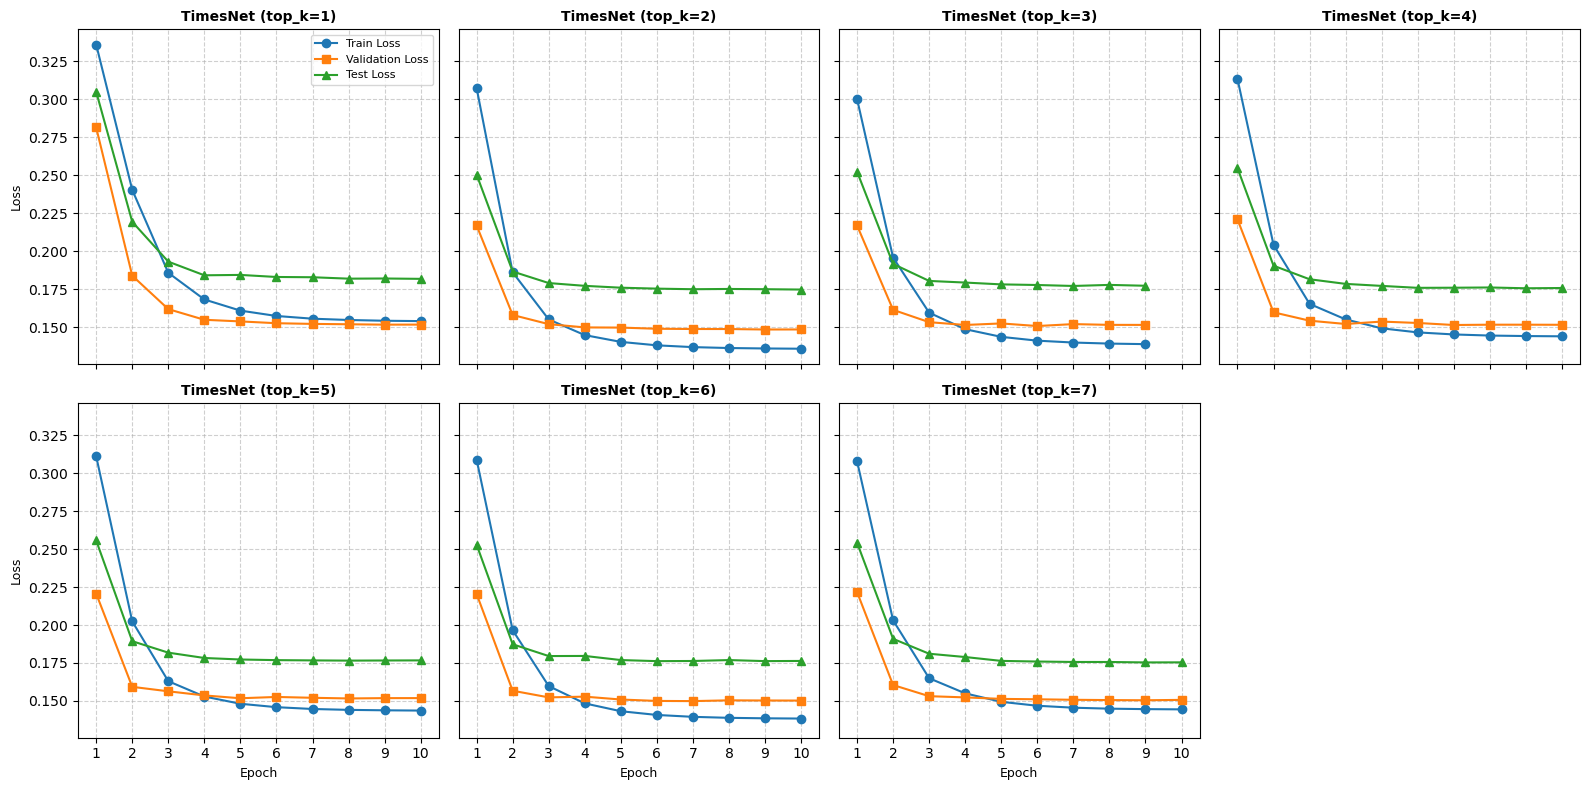

In [2]:
def plot_losses_all(
    ax,
    loss_data,
    title="",
    show_legend=False,
    show_ylabel=False,
    show_xlabel=False,
):
    if isinstance(loss_data, np.ndarray):
        loss_data = loss_data.item()

    num_epochs = len(loss_data["train_loss"])
    epochs = np.arange(1, num_epochs + 1)

    # Standardized color and marker scheme matching earlier loss plots
    ax.plot(epochs, loss_data["train_loss"], label="Train Loss", marker="o")
    ax.plot(epochs, loss_data["val_loss"], label="Validation Loss", marker="s")
    ax.plot(epochs, loss_data["test_loss"], label="Test Loss", marker="^")

    ax.set_title(title, fontsize=10, fontweight="bold")

    if show_xlabel:
        ax.set_xlabel("Epoch", fontsize=9)
    if show_ylabel:
        ax.set_ylabel("Loss", fontsize=9)

    # Fixed 1-10 vector x-axis limits
    ax.set_xticks(np.arange(1, 11))
    ax.set_xlim(0.5, 10.5)

    ax.grid(True, linestyle="--", alpha=0.6)

    if show_legend:
        ax.legend(frameon=True, fontsize=8)


# --- Setup Parameters ---
k_values = list(range(1, 8))  # k from 1 to 7
num_plots = len(k_values)

# Arrange into a 2-row grid (4 columns top row, 3 columns bottom row)
num_cols = 4
num_rows = 2

fig, axs = plt.subplots(
    num_rows, num_cols, figsize=(16, 8), sharey=True, sharex=True
)
axs_flat = axs.flatten()

for idx, k in enumerate(k_values):
    ax = axs_flat[idx]

    # Calculate row and column indices for conditional labels
    r = idx // num_cols
    c = idx % num_cols

    is_leftmost = c == 0
    is_bottom = (r == num_rows - 1) or (idx == num_plots - 1)
    is_first_plot = idx == 0

    path = f"./checkpoints/TimesNet_sl96_pl96_dm128_el2_tk{k}/loss_history.npy"

    try:
        losses = np.load(path, allow_pickle=True)
        plot_losses_all(
            ax,
            losses,
            title=f"TimesNet (top_k={k})",
            show_legend=is_first_plot,
            show_ylabel=is_leftmost,
            show_xlabel=is_bottom,
        )
    except FileNotFoundError:
        ax.set_title(
            f"Missing Data (top_k={k})", fontsize=10, color="red"
        )
        ax.set_xticks(np.arange(1, 11))
        ax.set_xlim(0.5, 10.5)
        ax.grid(True, linestyle="--", alpha=0.6)

        if is_leftmost:
            ax.set_ylabel("Loss", fontsize=9)
        if is_bottom:
            ax.set_xlabel("Epoch", fontsize=9)

# Hide the empty 8th subplot in the 2x4 grid
if num_plots < len(axs_flat):
    fig.delaxes(axs_flat[-1])

plt.tight_layout()
plt.savefig(
    "timesnet_topk_loss_comparison.png", bbox_inches="tight", dpi=300
)
plt.show()

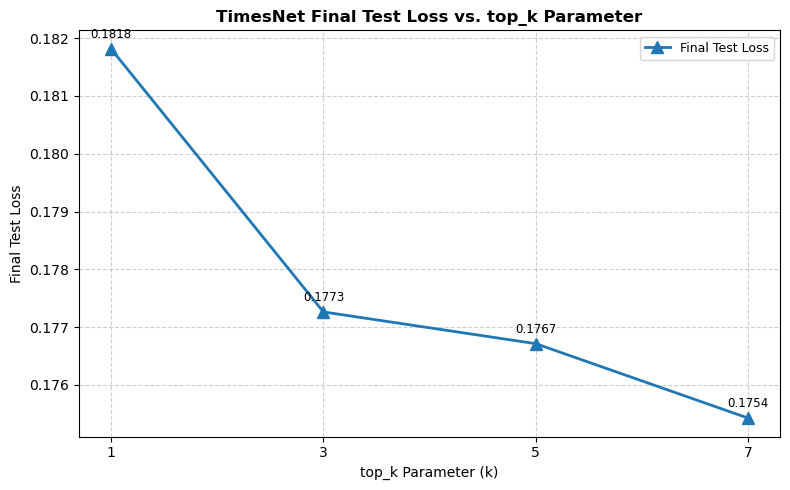

In [6]:
# --- Setup Parameters ---
k_values = [1,3,5,7]# list(range(1, 8))  # k from 1 to 7
final_test_losses = []

# --- Extract Final Test Loss for Each k ---
for k in k_values:
    path = f"./checkpoints/TimesNet_sl96_pl96_dm128_el2_tk{k}/loss_history.npy"

    try:
        losses = np.load(path, allow_pickle=True)
        if isinstance(losses, np.ndarray):
            losses = losses.item()

        # Extract the last epoch's test loss
        final_test_loss = losses["test_loss"][-1]
        final_test_losses.append(final_test_loss)
    except (FileNotFoundError, KeyError, IndexError):
        print(f"Warning: Checkpoint or test_loss missing for top_k={k}")
        final_test_losses.append(np.nan)

# Convert to array for easier masking/plotting
final_test_losses = np.array(final_test_losses)

# --- Plotting ---
plt.figure(figsize=(8, 5))

# Plot line with markers (using blue triangle '^' to match test loss marker style)
plt.plot(
    k_values,
    final_test_losses,
    marker="^",
    color="#1f77b4",
    linewidth=2,
    markersize=8,
    label="Final Test Loss",
)

# Highlight the best (minimum) loss point
valid_mask = ~np.isnan(final_test_losses)
if np.any(valid_mask):
    best_idx = np.nanargmin(final_test_losses)
    best_k = k_values[best_idx]
    best_loss = final_test_losses[best_idx]

    # plt.plot(
    #     best_k,
    #     best_loss,
    #     marker="o",
    #     color="red",
    #     markersize=10,
    #     label=f"Min Loss (k={best_k}: {best_loss:.4f})",
    # )

    # Annotate numeric values next to each data point
    for k, loss in zip(k_values, final_test_losses):
        if not np.isnan(loss):
            plt.annotate(
                f"{loss:.4f}",
                (k, loss),
                textcoords="offset points",
                xytext=(0, 8),
                ha="center",
                fontsize=8.5,
            )

# Style details
plt.title(
    "TimesNet Final Test Loss vs. top_k Parameter",
    fontsize=12,
    fontweight="bold",
)
plt.xlabel("top_k Parameter (k)", fontsize=10)
plt.ylabel("Final Test Loss", fontsize=10)
plt.xticks(k_values)
plt.grid(True, linestyle="--", alpha=0.6)
plt.legend(frameon=True, fontsize=9)

plt.tight_layout()
plt.savefig("timesnet_test_loss_vs_topk.png", bbox_inches="tight", dpi=300)
plt.show()

---

# PREDICTION EXAMPLES

In [40]:
# def plot_prediction(sample_input, sample_true, sample_pred, save_path, save=True, channel=0, sample_idx=0 ):
#     """
#     Plot TimesNet-style forecasting results.

#     Args:
#         sample_input: [N, seq_len, C]
#         sample_true:  [N, pred_len, C]
#         sample_pred:  [N, pred_len, C]
#         channel: which variable (0..320)
#         sample_idx: which sample in batch
#     """

#     # -------------------------------------------------------
#     # Extract single series
#     # -------------------------------------------------------
#     x_input = sample_input[sample_idx, :, channel]   # [seq_len]
#     x_true  = sample_true[sample_idx, :, channel]    # [pred_len]
#     x_pred  = sample_pred[sample_idx, :, channel]    # [pred_len]

#     seq_len = len(x_input)
#     pred_len = len(x_pred)

#     # -------------------------------------------------------
#     # TIME AXIS
#     # -------------------------------------------------------
#     # past: negative time
#     # future: starts at 0
#     # -------------------------------------------------------
#     t_past = np.arange(-seq_len, 0)
#     t_future = np.arange(0, pred_len)

#     # full ground truth (past + future)
#     full_true = np.concatenate([x_input, x_true])
#     t_full = np.arange(-seq_len, pred_len)

#     # -------------------------------------------------------
#     # PLOT
#     # -------------------------------------------------------
#     plt.figure(figsize=(14, 6))

#     # ground truth (past + future)
#     plt.plot(
#         t_full,
#         full_true,
#         color="gray",
#         linewidth=2,
#         label="Ground Truth"
#     )

#     # prediction (future only)
#     plt.plot(
#         t_future,
#         x_pred,
#         color="orange",
#         linewidth=2,
#         label="Prediction"
#     )

#     # vertical split at prediction start
#     plt.axvline(x=0, color="black", linestyle="--", linewidth=1, alpha=0.3)

#     # -------------------------------------------------------
#     # STYLE
#     # -------------------------------------------------------
#     plt.title(f"Forecasting Result (channel {channel})")
#     plt.xlabel("Time (hours)")
#     plt.ylabel("Electricity consumption (a.u.)")

#     plt.legend()
#     plt.grid(alpha=0.3)

#     if save == True:
#         plt.savefig(save_path, bbox_inches='tight', dpi=300)
#     plt.show()

In [41]:
# root_path = "checkpoints/sl96_pl96_dm64_el2_tk5/"

# inputs = np.load(os.path.join(root_path, "sample_input.npy"))
# trues = np.load(os.path.join(root_path, "sample_true.npy"))
# preds = np.load(os.path.join(root_path, "sample_pred.npy"))
# save_path = os.path.join(root_path, "prediction_example.png")

# plot_prediction(inputs, trues, preds,save_path, save=True, channel=5, sample_idx=0)

In [42]:
# root_path = "checkpoints/TCN_sl96_pl96_dm128_el2_tk5/"

# inputs = np.load(os.path.join(root_path, "sample_input.npy"))
# trues = np.load(os.path.join(root_path, "sample_true.npy"))
# preds = np.load(os.path.join(root_path, "sample_pred.npy"))
# save_path = os.path.join(root_path, "prediction_example.png")

# plot_prediction(inputs, trues, preds,save_path, save=False, channel=5, sample_idx=0)

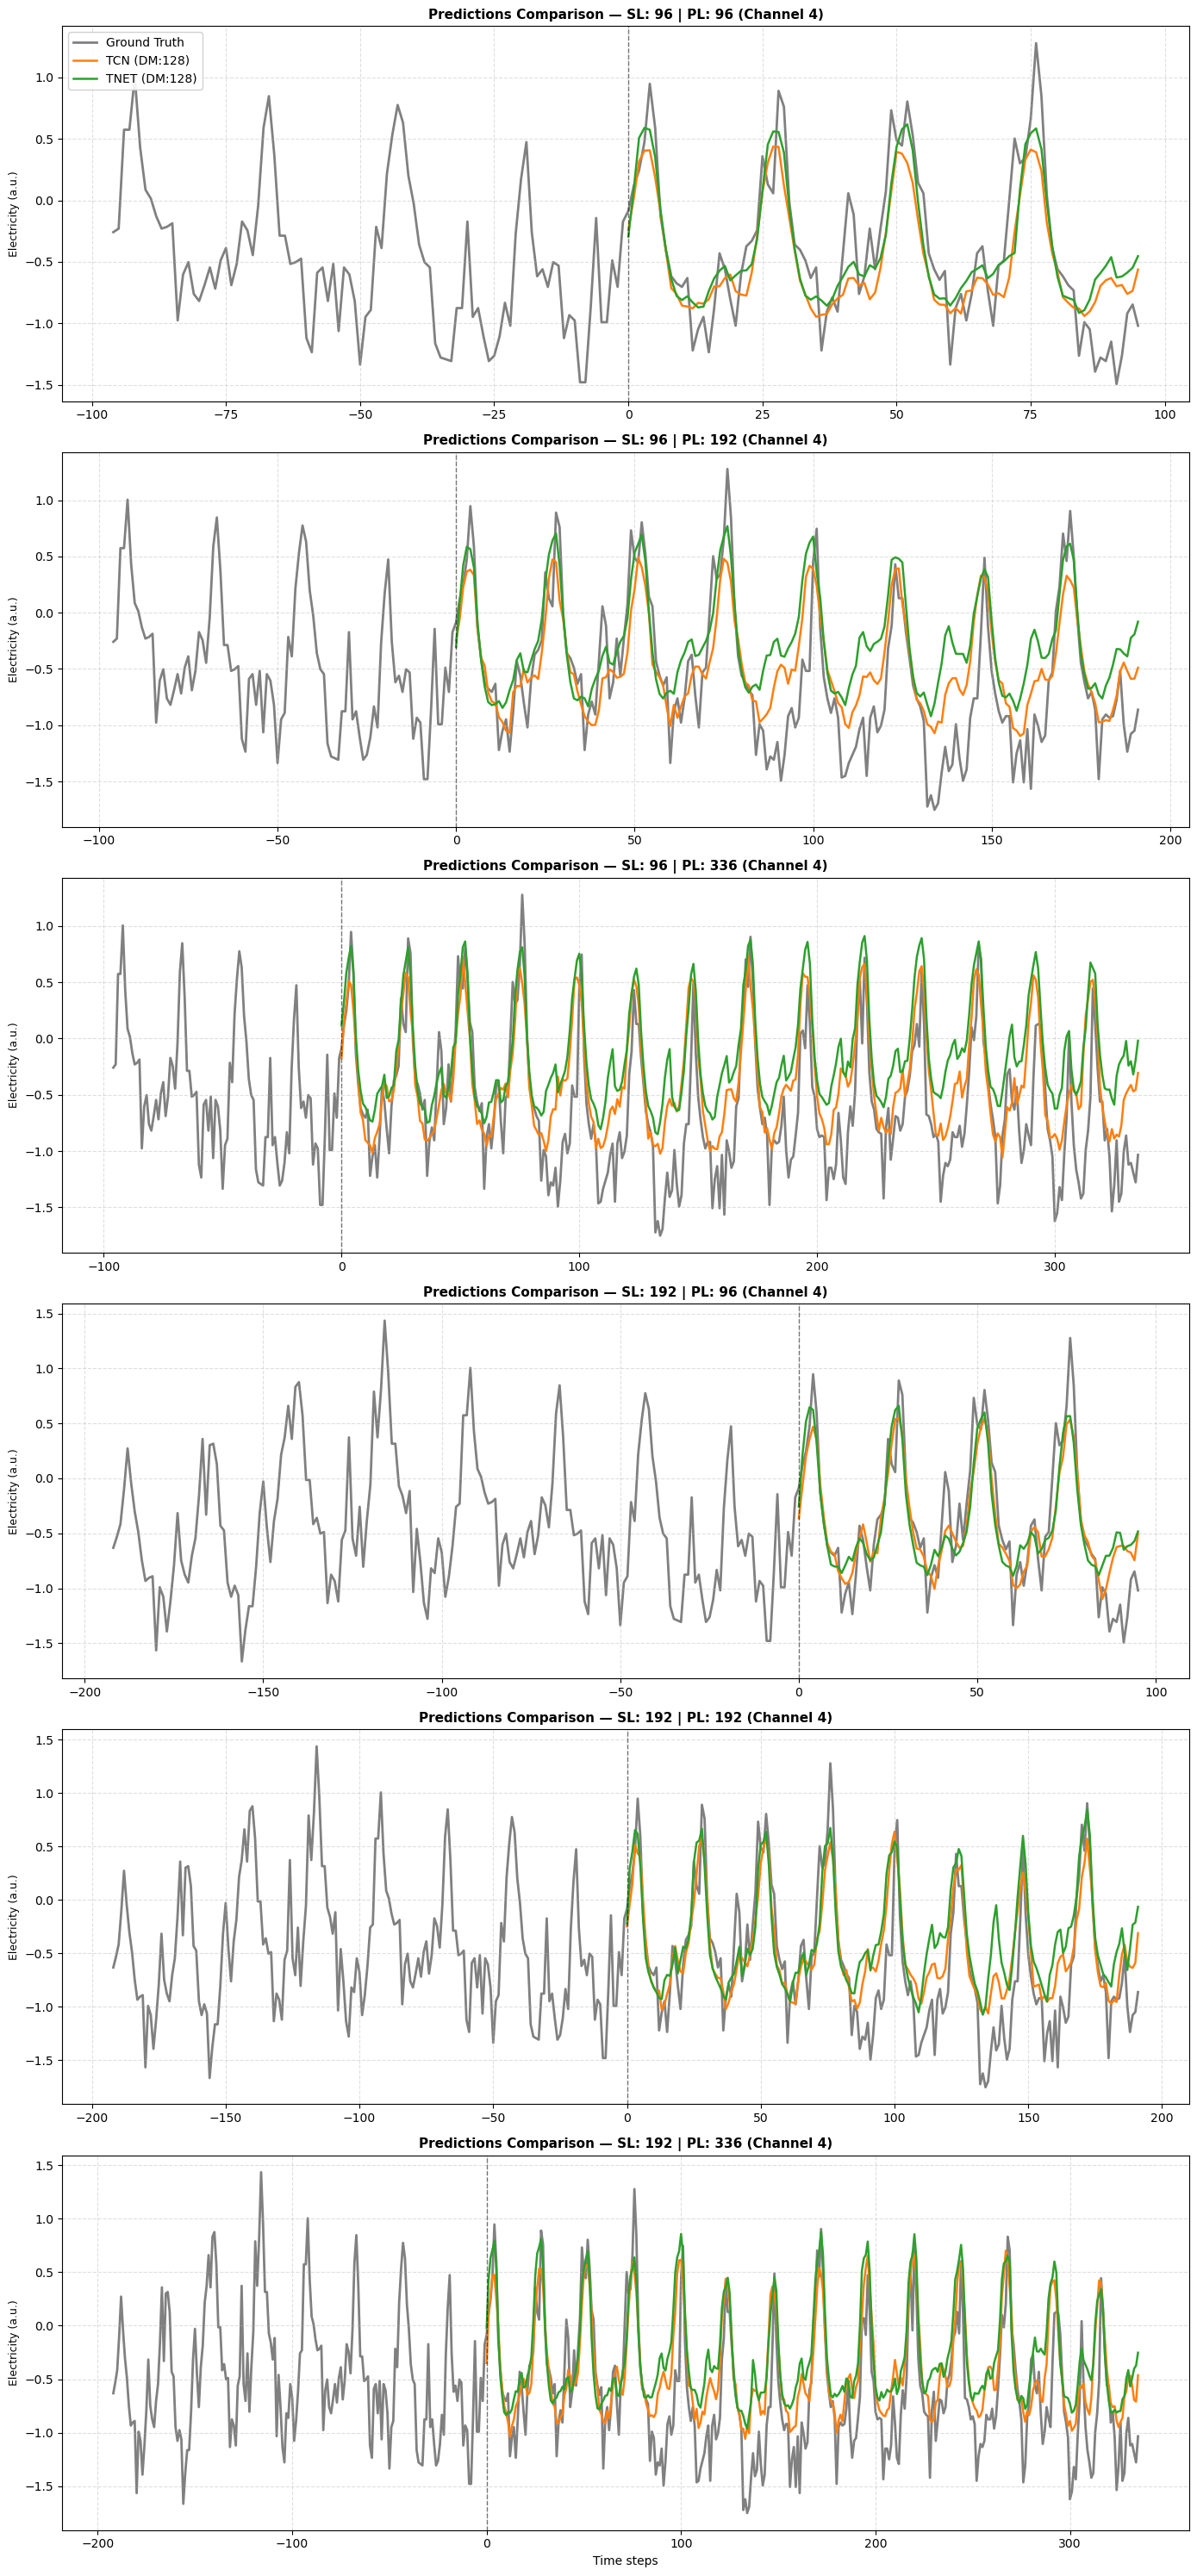

In [31]:
# --- Setup parameters ---
seq_lengths = [96, 192]
pred_lengths = [96, 192, 336]
d_models = [128]
channel = 4
sample_idx = 0
models = [("TCN", "TCN"), ("TimesNet", "TNET")]

# 4 Model configurations to compare on each plot
model_configs = []
for dm in d_models:
    for model_folder, label in models:
        model_configs.append((model_folder, label, dm))

# 6 (sl, pl) hyperparameter pairs -> 6 rows
param_pairs = list(itertools.product(seq_lengths, pred_lengths))
num_rows = len(param_pairs)

# Distinct colors for the 4 model predictions
model_colors = ["#ff7f0e", "#2ca02c", "#d62728", "#9467bd"]  # Orange, Green, Red, Purple

# --- Plotting ---
fig, axs = plt.subplots(
    num_rows, 1, figsize=(14, 5 * num_rows), sharey=False
)
if num_rows == 1:
    axs = [axs]

for r, (sl, pl) in enumerate(param_pairs):
    ax = axs[r]
    is_first_plot = r == 0
    is_last_plot = r == num_rows - 1

    gt_plotted = False  # Track ground truth plotting

    for m_idx, (model_folder, label, dm) in enumerate(model_configs):
        root_path = f"./checkpoints/{model_folder}_sl{sl}_pl{pl}_dm{dm}_el2_tk5/"

        input_path = os.path.join(root_path, "sample_input.npy")
        true_path = os.path.join(root_path, "sample_true.npy")
        pred_path = os.path.join(root_path, "sample_pred.npy")

        try:
            inputs = np.load(input_path)
            trues = np.load(true_path)
            preds = np.load(pred_path)

            x_input = inputs[sample_idx, :, channel]  # [seq_len]
            x_true = trues[sample_idx, :, channel]  # [pred_len]
            x_pred = preds[sample_idx, :, channel]  # [pred_len]

            seq_len = len(x_input)
            pred_len = len(x_pred)

            t_future = np.arange(0, pred_len)

            # Plot Ground Truth ONCE per row
            if not gt_plotted:
                full_true = np.concatenate([x_input, x_true])
                t_full = np.arange(-seq_len, pred_len)

                ax.plot(
                    t_full,
                    full_true,
                    color="gray",
                    linewidth=2,
                    label="Ground Truth",
                    zorder=1,
                )
                gt_plotted = True

            # Plot Model Prediction
            ax.plot(
                t_future,
                x_pred,
                color=model_colors[m_idx],
                linewidth=1.8,
                label=f"{label} (DM:{dm})",
                zorder=2,
            )

        except FileNotFoundError:
            print(
                f"Missing checkpoint: {model_folder}_sl{sl}_pl{pl}_dm{dm}_el2_tk5"
            )

    # Vertical split line at prediction start
    ax.axvline(x=0, color="black", linestyle="--", linewidth=1, alpha=0.5)

    # Style each row subplot
    ax.set_title(
        f"Predictions Comparison — SL: {sl} | PL: {pl} (Channel {channel})",
        fontsize=11,
        fontweight="bold",
    )
    ax.set_ylabel("Electricity (a.u.)", fontsize=9)
    ax.grid(True, linestyle="--", alpha=0.4)

    if is_last_plot:
        ax.set_xlabel("Time steps", fontsize=10)

    # Show legend only on the first row plot
    if is_first_plot:
        ax.legend(
            loc="upper left", frameon=True, facecolor="white", framealpha=0.9
        )

plt.tight_layout()
plt.savefig("all_predictions_comparison.png", bbox_inches="tight", dpi=300)
plt.show()

# 2D REPRESENTATIONS

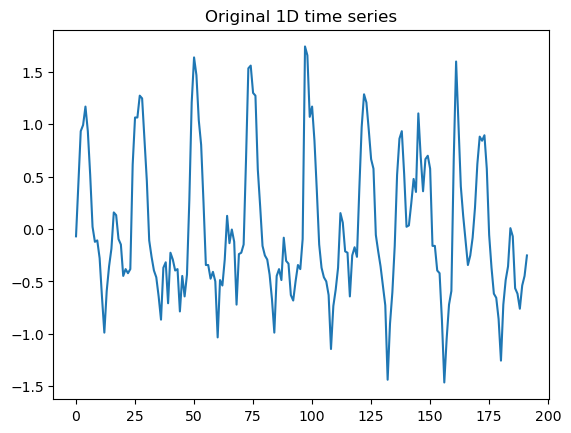

In [43]:
sample_idx =  0
channel_idx = 3

root_path = f"checkpoints/TimesNet_sl192_pl96_dm64_el2_tk5/"
file_path = f"x_sample{sample_idx}_ch{channel_idx}.npy"

x = np.load(os.path.join(root_path, file_path))

plt.plot(x)
plt.title("Original 1D time series")
plt.show()

In [44]:
# single period plot:
# file_path = "x2d_sample0_ch3_period12.npy"

# x2d = np.load(os.path.join(root_path, file_path))

# plt.imshow(x2d, aspect='auto', cmap='Blues')
# plt.colorbar()
# plt.title("2D representation (period = 12)")
# plt.xlabel("Intra-period (time within cycle)")
# plt.ylabel("Inter-period (cycle index)")
# plt.show()

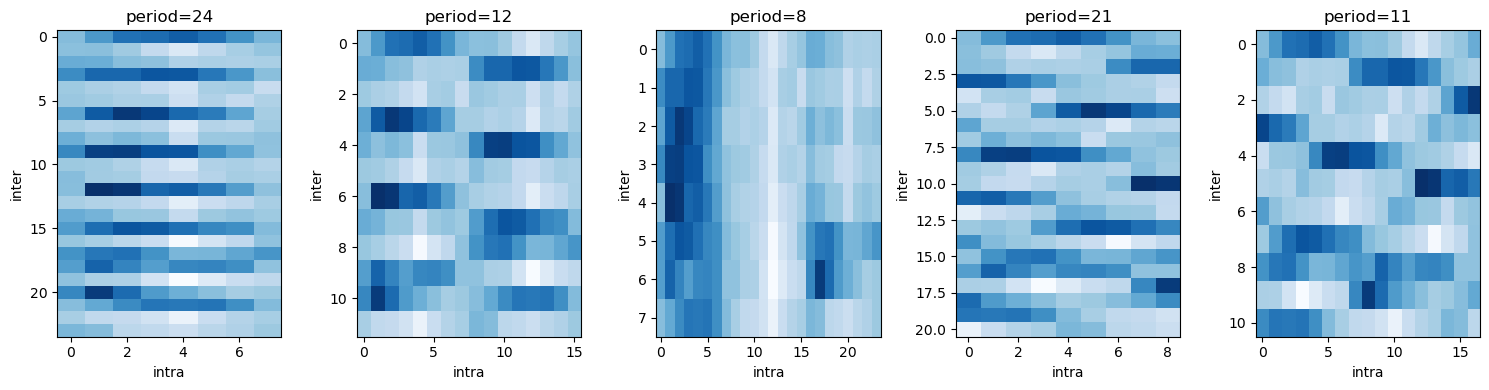

In [45]:
file_path = f"periods_sample{sample_idx}_ch{channel_idx}.npy"
periods = np.load(os.path.join(root_path, file_path))

fig, axes = plt.subplots(1, len(periods), figsize=(15, 4))

for i, p in enumerate(periods):
    file_path = f"x2d_sample{sample_idx}_ch{channel_idx}_period{p}.npy"
    x2d = np.load(os.path.join(root_path, file_path))
    
    axes[i].imshow(x2d, aspect='auto', cmap='Blues')
    axes[i].set_title(f"period={p}")
    axes[i].set_xlabel("intra")
    axes[i].set_ylabel("inter")

plt.tight_layout()
plt.show()

Good pairs of sample-channel: 0-3

Remember: we follow the **$[p, f]$** shape convention of the 2D matrixes, where **rows = intra-period time $p$**, and **columns = inter-period cycles $f$**:

The 2D representation is a reorganization of the original time series, obtained by *folding the signal according to a detected period*.

---

Each 2D matrix corresponds to taking a one-dimensional signal $x[t]$ of length $T$, selecting a candidate period $p$, and reshaping it into a matrix of shape approximately $[p, f]$, where $f \approx T/p$. In this construction, each row corresponds to a fixed position inside the period, while each column corresponds to a different repetition of that same period over time. In other words, if you imagine slicing the signal into consecutive segments of length $p$, each segment becomes a column, and rows align points that occupy the same relative position within each cycle.

This is the key mental model: the vertical axis encodes *time within a cycle*, while the horizontal axis encodes *which cycle you are in*. So when you move top to bottom inside a column, you are moving through one periodic unit; when you move left to right inside a row, you are observing how that same phase evolves across multiple repetitions.

---

A **vertical gradient** means that values change systematically within a single period. This suggests that the intra-period structure is not flat but has a temporal evolution: some phases of the cycle are consistently higher or lower than others. For instance, a smooth top-to-bottom increase indicates that each cycle follows a progressive rise over its duration, while a top-to-bottom decrease indicates a decay within each period. In physical terms, this corresponds to a *structured evolution inside the periodic window*, rather than a purely stationary oscillation.

A **horizontal gradient** instead reflects changes across periods. If you observe a consistent upward or downward trend when moving from left to right, it means that the system is evolving over longer time scales beyond the periodic repetition itself. Each cycle is similar in shape, but its overall level is drifting. This is exactly what the TimesNet paper refers to as *inter-period variation*: the periodic structure is preserved, but the baseline or amplitude changes gradually across time. In real-world terms, this often corresponds to long-term trends such as increasing consumption, decreasing demand, or seasonal drift.

---

The most informative structures often come from localized high or low intensity spots. An isolated bright or dark region in this matrix indicates that a specific phase of a specific cycle deviates strongly from the expected periodic pattern. Since columns represent cycles and rows represent phase positions, such a spot means that a particular moment within a specific repetition behaves unusually compared to the rest.

If such anomalies appear aligned horizontally, they indicate that a specific phase is consistently anomalous across many cycles. This can suggest that some specific point within the period is structurally unstable or more sensitive to external effects. Conversely, if anomalies appear vertically, it means that within a single cycle there are localized events that do not propagate across time, such as short bursts or spikes.

More generally, isolated spots reveal *non-periodic perturbations* superimposed on an otherwise structured periodic signal. These are particularly important because they represent information that pure periodic modeling would struggle to capture, yet convolutional operations in the 2D space can still detect and exploit them.

---

In summary, the 2D representation should not be read as an image in the usual sense, but as a coordinate system where one axis encodes repetition and the other encodes intra-cycle structure. Vertical variations describe the shape of one cycle, horizontal variations describe evolution across cycles, and isolated points represent local deviations from periodic regularity.

# PERIODICITY HISTOGRAM

In [53]:
data

{'periods': array([ 4,  6,  8, 12, 13, 19, 24, 32, 48, 96]),
 'density': array([1.99824561e-01, 1.00000000e-01, 1.00000000e-01, 1.00000000e-01,
        1.75438596e-04, 1.00000000e-01, 1.00000000e-01, 1.00000000e-01,
        1.00000000e-01, 1.00000000e-01]),
 'raw_periods': array([24, 12,  8, ..., 19,  4,  4], shape=(5700,))}

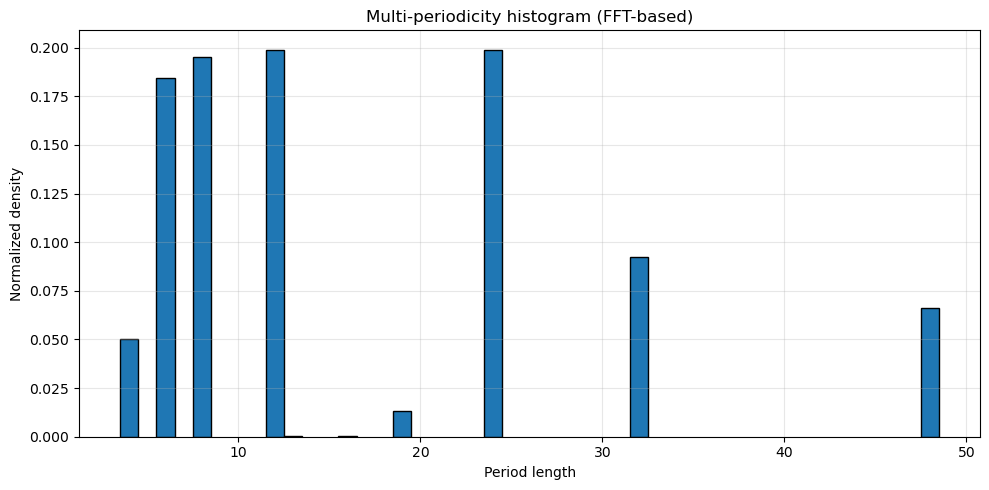

In [55]:
# ----------------------------
# Load periodicity histogram
# ----------------------------

k_value = 5  # must match what you used in FFT (top-k frequencies)

root_path = f"checkpoints/TimesNet_sl96_pl96_dm64_el2_tk5/"
file_path = "period_hist.npy"

data = np.load(os.path.join(root_path, file_path), allow_pickle=True).item()

# Extract saved arrays
periods = data["periods"]
density = data["density"]

# ----------------------------
# Filter out extreme period (96)
# ----------------------------
# In many cases T=96 appears as degenerate "full-length period"
mask = periods != 96

periods_filtered = periods[mask]
density_filtered = density[mask]

# ----------------------------
# Normalize density again (safety)
# ----------------------------
density_filtered = density_filtered / density_filtered.sum()

# ----------------------------
# Plot
# ----------------------------
plt.figure(figsize=(10, 5))

plt.bar(periods_filtered, density_filtered, width=1.0, edgecolor="black")

plt.xlabel("Period length")
plt.ylabel("Normalized density")
plt.title("Multi-periodicity histogram (FFT-based)")

plt.grid(alpha=0.3)
plt.tight_layout()

plt.show()